In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import warnings
import random

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

## 1. Parameters and Setup
BASE_DIR = 'phonemes'  # Script ke saath waala folder
SR = 22050
N_MELS = 128

# --- YEH HAI KEY ---
# Har phoneme file ke 100 version banayenge
AUGMENTATION_FACTOR = 100 

# Training Parameters
EPOCHS = 25         # Max epochs (Early Stopping use karenge)
BATCH_SIZE = 32

## 2. Helper Functions (Aapke puraane code se)

def extract_mel_spectrogram(y, sr=SR, n_mels=N_MELS):
    """Audio (y) ko Mel Spectrogram (dB) mein convert karta hai."""
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def augment_audio(y, sr=SR):
    """Audio (y) par randomly ek audio-level augmentation apply karta hai."""
    # 'none' ko hata diya taaki har copy thodi alag ho
    choice = np.random.choice(['pitch', 'stretch', 'noise'])
    
    if choice == 'pitch':
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-1, 1))
    elif choice == 'stretch':
        rate = np.random.uniform(0.9, 1.1)
        y = librosa.effects.time_stretch(y, rate=rate)
    elif choice == 'noise':
        y = y + 0.003 * np.random.randn(len(y))
    return y

def spec_augment(mel_spectrogram, time_mask_max=40, freq_mask_max=12):
    """Spectrogram (image) par Time aur Frequency masking apply karta hai."""
    mel_spec_aug = mel_spectrogram.copy()
    freq_dim, time_dim = mel_spec_aug.shape
    
    # Freq Mask
    freq_mask_num = np.random.randint(0, freq_mask_max)
    f_zero = np.random.randint(0, freq_dim - freq_mask_num)
    mel_spec_aug[f_zero:f_zero + freq_mask_num, :] = np.mean(mel_spec_aug)

    # Time Mask
    time_mask_num = np.random.randint(0, time_mask_max)
    t_zero = np.random.randint(0, time_dim - time_mask_num)
    mel_spec_aug[:, t_zero:t_zero + time_mask_num] = np.mean(mel_spec_aug)
    
    return mel_spec_aug

## 3. Data Loading and MASSIVE Augmentation
print("Starting data loading and augmentation...")

X, y = [], []
original_files = [] # Prediction ke liye original files save karenge

try:
    # os.walk aapke saare subfolders (nasal, fricatives...) mein jaayega
    for root, dirs, files in os.walk(BASE_DIR):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                
                # --- YEH HAI AAPKA LABEL ---
                # Filename (e.g., "θ.wav") se ".wav" hataya
                label = file.split('.')[0]
                
                try:
                    # Original audio ko ek baar load karo
                    y_raw, sr_load = librosa.load(file_path, sr=SR)
                    
                    # Original file ko prediction test ke liye save karo
                    original_files.append((file_path, label))

                    # --- Augmentation Loop ---
                    for i in range(AUGMENTATION_FACTOR):
                        # 1. Audio Augmentation
                        y_aug = augment_audio(y_raw, SR)
                        
                        # 2. Feature Extraction
                        mel_db = extract_mel_spectrogram(y_aug, sr=SR, n_mels=N_MELS)
                        
                        # 3. Spectrogram Augmentation
                        mel_spec_aug = spec_augment(mel_db)
                        
                        X.append(mel_spec_aug)
                        y.append(label)
                        
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    print(f"Data processing complete. Total samples created: {len(X)}")
    print("-" * 30)

    ## 4. Padding (Sabko same size karna)
    print("Padding spectrograms to uniform length...")
    max_length = max(mel.shape[1] for mel in X)
    print(f"Maximum spectrogram length: {max_length}")

    X_padded = []
    for mel in X:
        pad_width = ((0, 0), (0, max_length - mel.shape[1]))
        padded_mel = np.pad(mel, pad_width=pad_width, mode='constant', constant_values=np.min(mel))
        X_padded.append(padded_mel)

    X = np.array(X_padded)
    y = np.array(y)
    
    # Channel dimension add karo (Model ke liye)
    X = X[..., np.newaxis]

    print(f"Final shape of X (features): {X.shape}")
    print(f"Final shape of y (labels): {y.shape}")
    print("-" * 30)

    ## 5. Encoding & Splitting
    print("Encoding labels and splitting data...")
    
    # LabelEncoder 'θ', 'tʃ' jaise text labels ko 0, 1, 2...43 mein badal dega
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    num_classes = len(le.classes_)
    
    print(f"Total classes found: {num_classes}")
    # print(le.classes_) # Saare 44 phonemes print karega
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_encoded # Har phoneme ke samples train/test mein barabar baanto
    )
    print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
    print("-" * 30)

    ## 6. Build the 2D-CNN Model
    input_shape = X_train.shape[1:]  # (N_MELS, max_length, 1)

    print(f"Building model for {num_classes} classes...")
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        # --- YEH KEY CHANGE HAI ---
        # Ab yeh 44 output dega
        layers.Dense(num_classes, activation='softmax') 
    ])

    ## 7. Compile & Train
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy', # 0-43 labels ke liye perfect
        metrics=['accuracy']
    )
    model.summary()
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    print("\nStarting model training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop]
    )
    print("Training complete.")
    print("-" * 30)

    ## 8. Evaluate
    print("Evaluating model performance...")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")
    print("-" * 30)

    ## 9. Prediction Test (Recognition)
    print("Running prediction test on ORIGINAL files...")
    
    # Model ko test karne ke liye, original files mein se random 5 chuno
    random.shuffle(original_files)
    
    for file_path, true_label in original_files[:5]:
        # 1. Original file ko load karo (bina augmentation)
        y_raw, sr = librosa.load(file_path, sr=SR)
        
        # 2. Features nikaalo
        mel_db = extract_mel_spectrogram(y_raw, sr=SR, n_mels=N_MELS)
        
        # 3. Pad karo (Training waali max_length tak)
        pad_width = ((0, 0), (0, max_length - mel_db.shape[1]))
        mel_padded = np.pad(mel_db, pad_width, mode='constant', constant_values=np.min(mel_db))
        
        # 4. Model ke liye shape ready karo (Batch, H, W, Channel)
        mel_ready = mel_padded[np.newaxis, ..., np.newaxis]
        
        # 5. Predict karo
        prediction_probs = model.predict(mel_ready)
        predicted_index = np.argmax(prediction_probs)
        predicted_label = le.inverse_transform([predicted_index])[0]
        
        print(f"\nFile: {file}")
        print(f"🎯 True Phoneme: '{true_label}'")
        print(f"🔥 Predicted Phoneme: '{predicted_label}'")
        if true_label == predicted_label:
            print("Result: CORRECT! 🎉")
        else:
            print("Result: WRONG. 👎")

except Exception as e:
    print(f"Ek bada error aa gaya: {e}")
    print("Check karo ki 'phonemes' folder script ke paas hai ya nahi.")

Starting data loading and augmentation...
Data processing complete. Total samples created: 4400
------------------------------
Padding spectrograms to uniform length...
Maximum spectrogram length: 127
Final shape of X (features): (4400, 128, 127, 1)
Final shape of y (labels): (4400,)
------------------------------
Encoding labels and splitting data...
Total classes found: 44
Training samples: 3520, Testing samples: 880
------------------------------
Building model for 44 classes...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 127, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 127, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 63, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 31, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 31, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 15, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 44)                  │           5,676 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 115,756 (452.17 KB)

 Trainable params: 115,308 (450.42 KB)

 Non-trainable params: 448 (1.75 KB)


Starting model training...
Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 89s 773ms/step - accuracy: 0.0668 - loss: 3.5667 - val_accuracy: 0.0318 - val_loss: 4.5935
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 84s 768ms/step - accuracy: 0.1713 - loss: 2.9386 - val_accuracy: 0.0659 - val_loss: 3.4348
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 95s 868ms/step - accuracy: 0.3724 - loss: 2.1823 - val_accuracy: 0.1295 - val_loss: 3.0846
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 84s 764ms/step - accuracy: 0.5423 - loss: 1.5766 - val_accuracy: 0.2795 - val_loss: 2.5331
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 783ms/step - accuracy: 0.7054 - loss: 1.1027 - val_accuracy: 0.3909 - val_loss: 2.0780
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 770ms/step - accuracy: 0.7795 - loss: 0.8328 - val_accuracy: 0.0841 - val_loss: 8.6589
Epoch 7/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 85s 769ms/step - accuracy: 0.8364 - loss: 0.6167 - val_accuracy: 0.5011 - val_loss: 1.6630
Epoch 8/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 755ms/st

  - Plosives: Selected 'g' from phonemes\plosives\g.wav
  - Nasals: Selected 'm' from phonemes\nasals\m.wav
  - Affricates: Selected 'tʃ' from phonemes\affricates\tʃ.wav
  - Fricatives: Selected 'z' from phonemes\fricatives\z.wav
  - Approximants: Selected 'j' from phonemes\approximants\j.wav
  - Diphthongs: Selected 'əʊ' from phonemes\diphthongs\əʊ.wav
  - Monophthongs: Selected 'ʊ' from phonemes\monophthongs\ʊ.wav


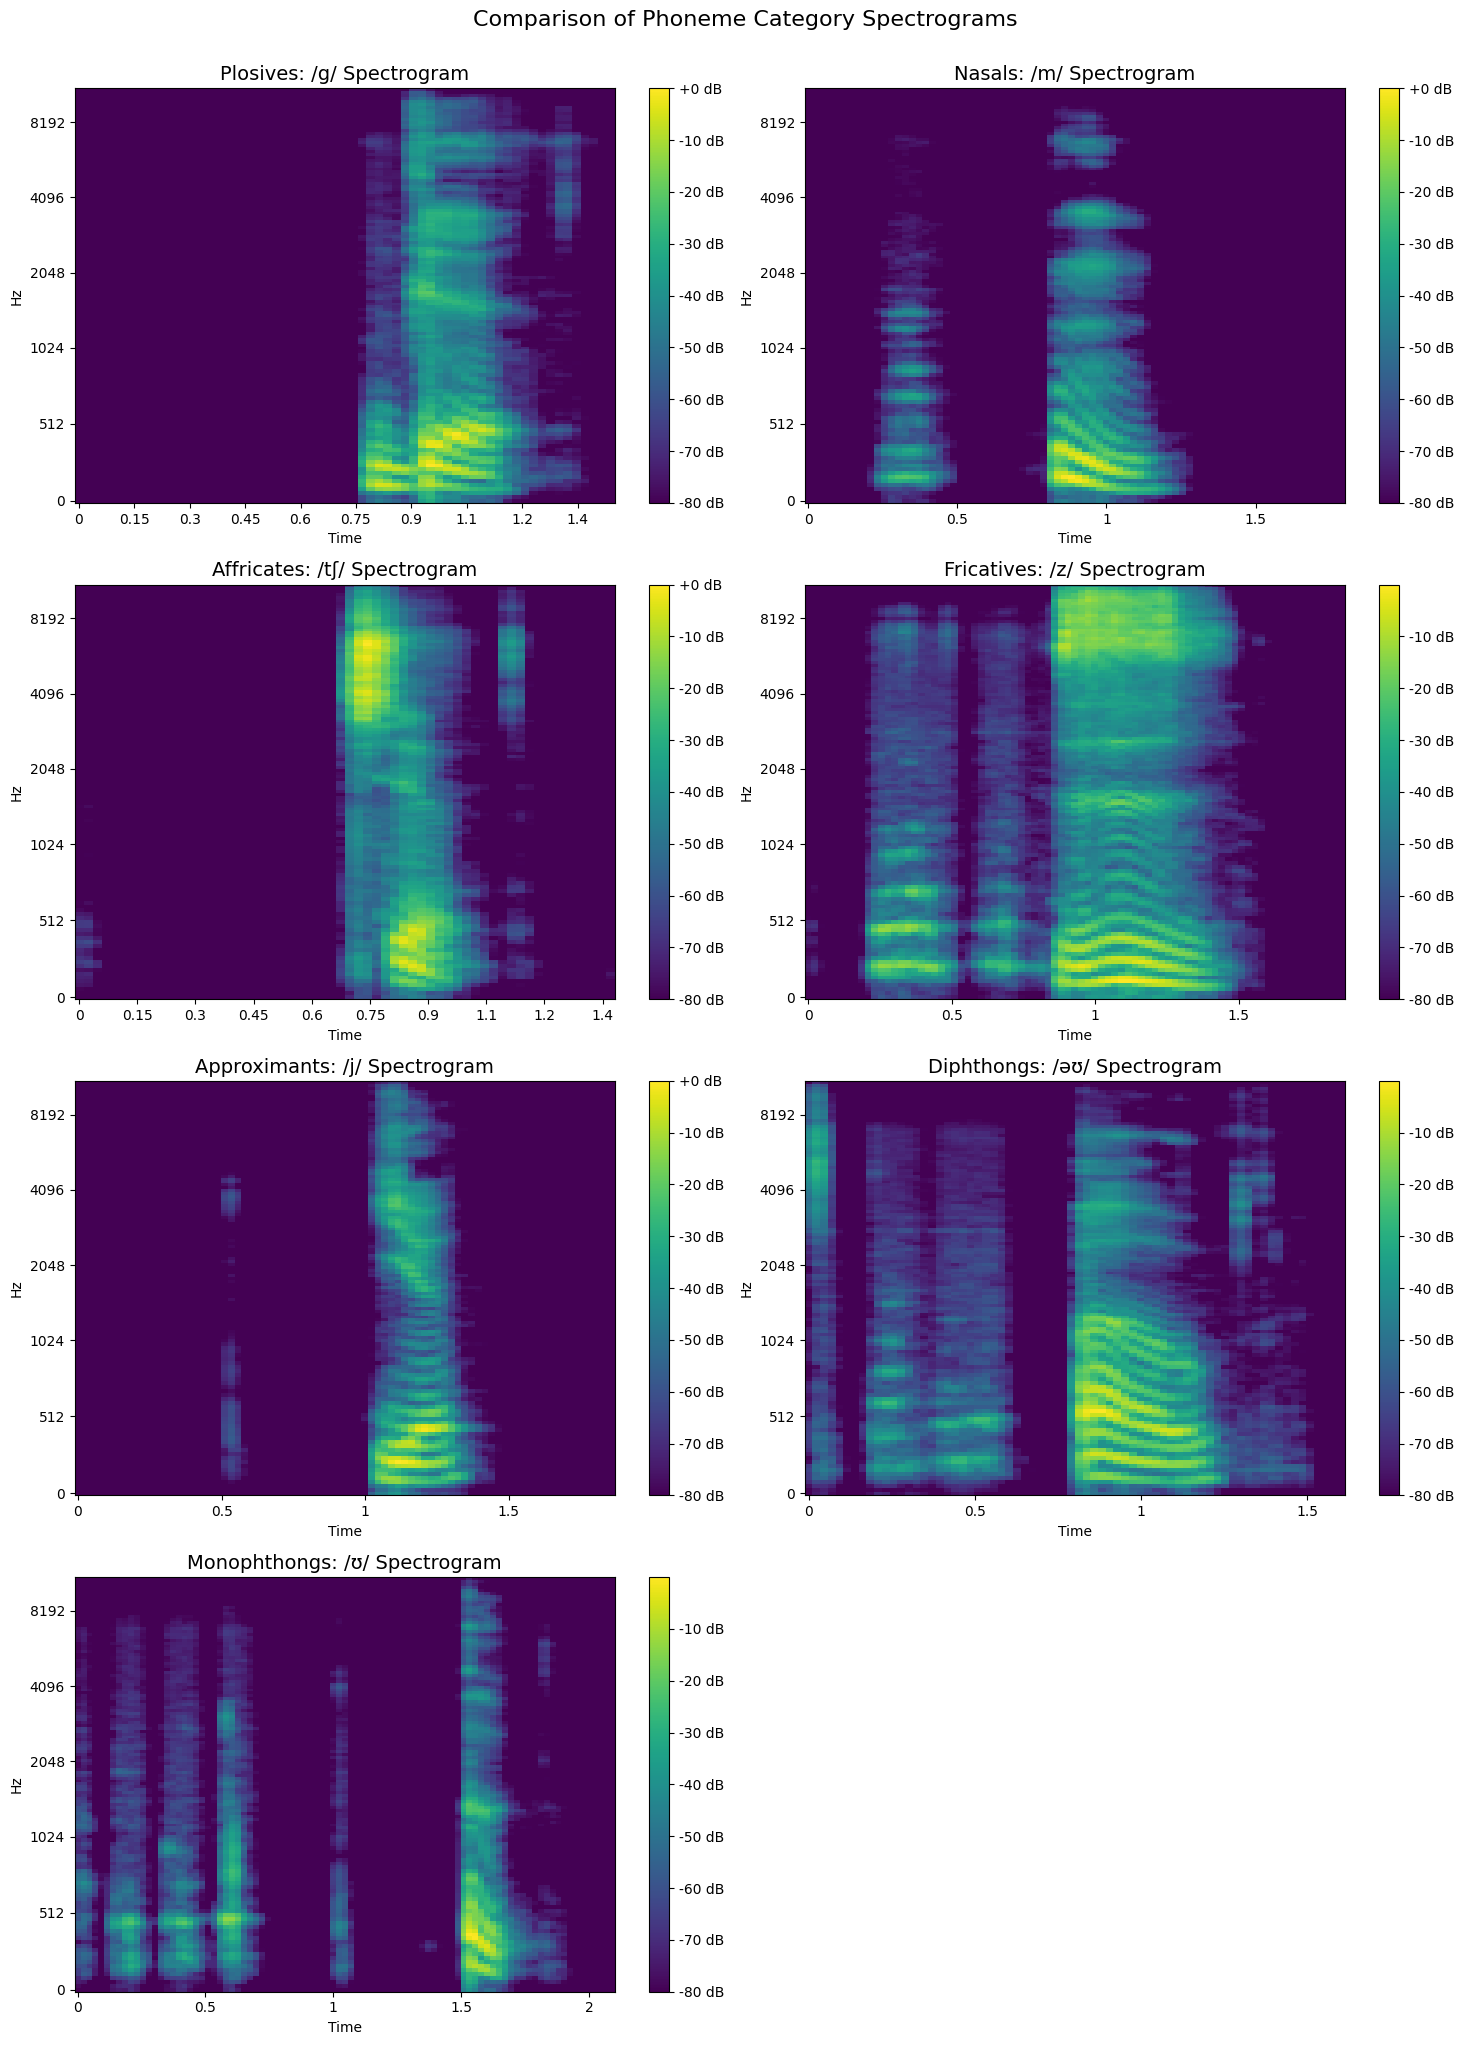

In [2]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

## 1. Parameters
BASE_DIR = 'phonemes'  # Aapka 'phonemes' folder
SR = 22050             # Sample Rate
N_MELS = 128           # Mel Spectrogram height

# Categories jinhe aap compare karna chahte hain
# Yahi aapke subfolder names hone chahiye
PHONEME_CATEGORIES = [
    'plosives',
    'nasals',
    'affricates',
    'fricatives',
    'approximants',
    'diphthongs',
    'monophthongs'
]

## 2. Helper Function (Spectrogram extraction)
def extract_mel_spectrogram(file_path, sr=SR, n_mels=N_MELS):
    """
    Ek audio file se Mel Spectrogram extract karta hai.
    """
    try:
        y, sr_load = librosa.load(file_path, sr=sr)
        mel = librosa.feature.melspectrogram(y=y, sr=sr_load, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return mel_db, y, sr_load
    except Exception as e:
        print(f"Error loading or processing {file_path}: {e}")
        return None, None, None

## 3. Main Logic: Collect, Process, Plot

if __name__ == "__main__":
    
    selected_phonemes = {} # Dictionary to store chosen file_path and label for each category

    print("Collecting a random phoneme from each category...")
    for category in PHONEME_CATEGORIES:
        category_path = os.path.join(BASE_DIR, category)
        
        if not os.path.exists(category_path):
            print(f"Warning: Category folder '{category_path}' not found. Skipping.")
            continue
            
        # Saari .wav files collect karo us category mein se
        wav_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
        
        if not wav_files:
            print(f"Warning: No .wav files found in '{category_path}'. Skipping.")
            continue
            
        # Ek random file chuno
        chosen_file = random.choice(wav_files)
        file_path = os.path.join(category_path, chosen_file)
        
        # Phoneme label (file name bina .wav ke)
        phoneme_label = chosen_file.replace('.wav', '')
        
        selected_phonemes[category] = {'path': file_path, 'label': phoneme_label}
        print(f"  - {category.capitalize()}: Selected '{phoneme_label}' from {file_path}")

    if not selected_phonemes:
        print("\nNo phonemes selected for plotting. Please check folder structure and file types.")
    else:
        # Plotting setup
        num_plots = len(selected_phonemes)
        # 2 columns mein arrange karenge, rows uske hisaab se
        num_cols = 2
        num_rows = (num_plots + num_cols - 1) // num_cols # Ceiling division

        plt.figure(figsize=(15, 5 * num_rows)) # Overall figure size

        plot_idx = 1
        for category, info in selected_phonemes.items():
            file_path = info['path']
            phoneme_label = info['label']
            
            mel_db, y_audio, sr_audio = extract_mel_spectrogram(file_path)
            
            if mel_db is None:
                continue

            plt.subplot(num_rows, num_cols, plot_idx)
            
            # Librosa display function use karenge
            librosa.display.specshow(mel_db, 
                                     sr=sr_audio, 
                                     x_axis='time', 
                                     y_axis='mel', 
                                     cmap='viridis') # 'viridis' ya 'magma' achha dikhta hai
            
            plt.colorbar(format='%+2.0f dB')
            plt.title(f"{category.capitalize()}: /{phoneme_label}/ Spectrogram", fontsize=14)
            plt.tight_layout() # Plots ke beech space maintain karta hai
            
            plot_idx += 1
        
        plt.suptitle("Comparison of Phoneme Category Spectrograms", fontsize=16, y=1.02)
        plt.show()